In [2]:
# ============================================================================
# SCRIPT UNIFICADO DE LIMPIEZA Y CONVERSIÓN DE DATOS
# ============================================================================

# ============================================================================
# CELL 1: IMPORTS Y CONFIGURACIÓN
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import warnings
import os
from pathlib import Path
import re

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✓ Librerías cargadas correctamente")


# ============================================================================
# CELL 2: CARGA INTELIGENTE DE DATOS
# ============================================================================
def cargar_datos_inteligente(filepath):
    """
    Carga automáticamente archivos CSV, Excel, JSON o Parquet.
    Detecta el encoding correcto para CSV.
    """
    filepath = Path(filepath)
    
    if not filepath.exists():
        raise FileNotFoundError(f"El archivo {filepath} no existe")
    
    print(f"Cargando archivo: {filepath.name}")
    
    suffix = filepath.suffix.lower()
    
    # Excel
    if suffix in ['.xlsx', '.xls']:
        df = pd.read_excel(filepath)
        print("✓ Formato: Excel")
    
    # CSV con detección de encoding
    elif suffix == '.csv':
        encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
        for encoding in encodings:
            try:
                df = pd.read_csv(filepath, encoding=encoding)
                print(f"✓ Formato: CSV (encoding: {encoding})")
                break
            except UnicodeDecodeError:
                continue
        else:
            raise ValueError("No se pudo decodificar el CSV con los encodings disponibles")
    
    # Parquet
    elif suffix == '.parquet':
        df = pd.read_parquet(filepath)
        print("✓ Formato: Parquet")
    
    # JSON
    elif suffix == '.json':
        df = pd.read_json(filepath)
        print("✓ Formato: JSON")
    
    else:
        raise ValueError(f"Formato no soportado: {suffix}")
    
    print(f"✓ Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
    return df


# ============================================================================
# CELL 3: DIAGNÓSTICO DE CALIDAD DE DATOS
# ============================================================================
def diagnosticar_calidad_datos(df):
    """
    Genera un reporte completo de calidad de datos.
    Detecta: tipos mixtos, nulos, outliers, alta cardinalidad, variancia cero.
    """
    print("\n" + "="*80)
    print("DIAGNÓSTICO DE CALIDAD DE DATOS")
    print("="*80)
    
    reporte = []
    
    for col in df.columns:
        info = {
            'Columna': col,
            'Tipo_Actual': str(df[col].dtype),
            'Total_Filas': len(df),
            'Nulos': df[col].isnull().sum(),
            '%_Nulos': round(df[col].isnull().sum() / len(df) * 100, 2),
            'Valores_Unicos': df[col].nunique(),
            'Flags': []
        }
        
        # Detección de tipos mixtos (object que debería ser numérico)
        if df[col].dtype == 'object':
            # Verificar si parece numérica pero tiene texto
            numericos_posibles = pd.to_numeric(df[col], errors='coerce')
            if numericos_posibles.notna().sum() > len(df) * 0.5:
                info['Flags'].append('POSIBLE_NUMERICA')
            
            # Verificar si parece fecha
            if df[col].str.contains(r'\d{1,4}[-/]\d{1,2}[-/]\d{1,4}', na=False, regex=True).sum() > len(df) * 0.3:
                info['Flags'].append('POSIBLE_FECHA')
        
        # Detección de outliers para numéricas
        if pd.api.types.is_numeric_dtype(df[col]):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
            info['%_Outliers'] = round(outliers / len(df) * 100, 2)
            if info['%_Outliers'] > 5:
                info['Flags'].append('OUTLIERS_EXTREMOS')
        else:
            info['%_Outliers'] = 'N/A'
        
        # Alta cardinalidad
        if df[col].nunique() > len(df) * 0.8:
            info['Flags'].append('ALTA_CARDINALIDAD')
        
        # Variancia cero
        if df[col].nunique() == 1:
            info['Flags'].append('VARIANCIA_CERO')
        
        info['Flags'] = ', '.join(info['Flags']) if info['Flags'] else 'OK'
        reporte.append(info)
    
    df_reporte = pd.DataFrame(reporte).sort_values('%_Nulos', ascending=False)
    
    # Mostrar resumen
    print(f"\n RESUMEN:")
    print(f"  - Columnas con nulos: {(df_reporte['%_Nulos'] > 0).sum()}")
    print(f"  - Columnas con outliers: {(df_reporte['Flags'].str.contains('OUTLIERS', na=False)).sum()}")
    print(f"  - Posibles fechas sin convertir: {(df_reporte['Flags'].str.contains('POSIBLE_FECHA', na=False)).sum()}")
    print(f"  - Posibles numéricas sin convertir: {(df_reporte['Flags'].str.contains('POSIBLE_NUMERICA', na=False)).sum()}")
    
    return df_reporte


# ============================================================================
# CELL 4: DETECCIÓN DE FILAS CORRIDAS
# ============================================================================
def detectar_filas_corridas(df):
    """
    Detecta patrones sospechosos de nulos que indican filas corridas o corruptas.
    """
    print("\n Detectando filas con patrones sospechosos...")
    
    alertas = []
    
    # Buscar filas donde una columna tiene valor pero TODAS las demás son nulas
    for col in df.columns:
        patron = df[col].notnull() & df.drop(columns=[col]).isnull().all(axis=1)
        if patron.sum() > 0 and patron.sum() < len(df) * 0.01:  # Menos del 1%
            alertas.append({
                'Tipo': 'FILA_CASI_VACIA',
                'Columna_con_valor': col,
                'Filas_Afectadas': patron.sum(),
                'Indices': df[patron].index.tolist()[:5]
            })
    
    if alertas:
        print(f" Se detectaron {len(alertas)} patrones sospechosos")
        return pd.DataFrame(alertas)
    else:
        print("  ✓ No se detectaron filas corridas")
        return pd.DataFrame()


# ============================================================================
# CELL 5: NORMALIZACIÓN DE CATEGORÍAS
# ============================================================================
def normalizar_categorias(df, columnas=None):
    """
    Unifica categorías similares automáticamente.
    Ej: 'femenino', 'f', 'female', 'F' → 'femenino'
    """
    print("\n Normalizando categorías...")
    
    if columnas is None:
        columnas = df.select_dtypes(include=['object']).columns
    
    # Diccionarios de mapeo comunes (puedes expandir esto)
    mapeos_comunes = {
        'genero': {
            'f': 'femenino', 'female': 'femenino', 'mujer': 'femenino', 'femenina': 'femenino',
            'm': 'masculino', 'male': 'masculino', 'hombre': 'masculino', 'masculina': 'masculino',
            'femenino': 'femenino', 'masculino': 'masculino'
        },
        'estado_civil': {
            'soltero': 'soltero', 'soltera': 'soltero', 'single': 'soltero',
            'casado': 'casado', 'casada': 'casado', 'married': 'casado',
            'divorciado': 'divorciado', 'divorciada': 'divorciado', 'divorced': 'divorciado',
            'viudo': 'viudo', 'viuda': 'viudo', 'widowed': 'viudo'
        },
        'si_no': {
            'si': 'si', 'sí': 'si', 'yes': 'si', 'y': 'si', 'true': 'si', '1': 'si',
            'no': 'no', 'n': 'no', 'false': 'no', '0': 'no'
        },
        'member_casual': {
            'member': 'member', 'casual': 'casual',
            'miembro': 'member', 'ocasional': 'casual'
        }
    }
    
    columnas_normalizadas = 0
    
    for col in columnas:
        # Convertir a string y limpiar
        df[col] = df[col].astype(str).str.strip().str.lower()
        
        # Reemplazar 'nan', 'none', etc. por NaN real
        df[col] = df[col].replace(['nan', 'none', 'na', 'n/a', 'null', ''], np.nan)
        
        # Buscar si hay un mapeo predefinido para esta columna
        for key_pattern, mapeo in mapeos_comunes.items():
            if key_pattern in col.lower():
                valores_unicos = df[col].dropna().unique()
                valores_a_mapear = {v: mapeo.get(v, v) for v in valores_unicos if v in mapeo}
                
                if valores_a_mapear:
                    df[col] = df[col].replace(valores_a_mapear)
                    columnas_normalizadas += 1
                    print(f"  ✓ {col}: {len(valores_a_mapear)} categorías unificadas")
                break
    
    print(f"  → Total de columnas normalizadas: {columnas_normalizadas}")
    return df


# ============================================================================
# CELL 6: CONVERSIÓN ROBUSTA DE FECHAS
# ============================================================================
def detectar_y_convertir_fechas(df, columnas=None, umbral=0.3):
    """
    Detecta columnas de fecha usando conversión directa (sin regex).
    Funciona para cualquier formato de fecha válido (incluyendo con hora).
    """
    print("\n Convirtiendo fechas con múltiples formatos...")
    
    if columnas is None:
        # DETECCIÓN AUTOMÁTICA MEJORADA (sin regex)
        columnas_fecha = []
        for col in df.select_dtypes(include=['object']).columns:
            # Intentar convertir a datetime
            try:
                # Si >30% de los valores se convierten exitosamente, es una fecha
                converted = pd.to_datetime(df[col], errors='coerce')
                if converted.notna().sum() > len(df) * umbral:
                    columnas_fecha.append(col)
            except:
                continue
        
        print(f"  → Detectadas {len(columnas_fecha)} columnas de fecha: {columnas_fecha}")
    else:
        columnas_fecha = columnas
    
    # Lista EXTENDIDA de formatos (con hora y sin hora)
    formatos_posibles = [
        # Formatos comunes (con hora)
        '%Y-%m-%d %H:%M:%S',
        '%Y-%m-%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M',
        # Formatos sin hora
        '%Y-%m-%d',
        '%Y/%m/%d',
        '%d-%m-%Y',
        '%d/%m/%Y',
        '%d-%m-%Y %H:%M:%S',
        '%d-%m-%Y %H:%M',
        '%d/%m/%Y %H:%M:%S',
        '%d/%m/%Y %H:%M',
        '%m-%d-%Y %H:%M:%S',
        '%m-%d-%Y',
        '%m/%d/%Y %H:%M:%S',
        '%m/%d/%Y',
        # ISO formats
        '%Y-%m-%dT%H:%M:%S',
        '%Y-%m-%dT%H:%M:%S.%f',
        '%Y-%m-%dT%H:%M:%SZ',
    ]
    
    columnas_convertidas = 0
    
    for col in columnas_fecha:
        print(f"\n  Procesando '{col}':")
        
        # Inicializar resultado como NaT
        resultado = pd.Series([pd.NaT] * len(df), index=df.index, dtype='datetime64[ns]')
        
        # Probar cada formato secuencialmente
        for i, fmt in enumerate(formatos_posibles, 1):
            mask = resultado.isna()
            faltantes = mask.sum()
            
            if faltantes == 0:
                break
            
            try:
                convertidas = pd.to_datetime(
                    df.loc[mask, col],
                    format=fmt,
                    errors='coerce'
                )
                
                resultado.loc[mask] = convertidas
                
                exitosas = convertidas.notna().sum()
                if exitosas > 0:
                    print(f"    {i}. {fmt:25s} → {exitosas:5d} ({exitosas/faltantes*100:5.1f}%)")
                    
            except Exception:
                continue
        
        # Último intento: inferencia automática (sin formato)
        mask = resultado.isna()
        if mask.sum() > 0:
            try:
                inferidas = pd.to_datetime(df.loc[mask, col], errors='coerce', dayfirst=False)
                resultado.loc[mask] = inferidas
                print(f"    → Inferencia automática: {inferidas.notna().sum()} adicionales")
            except:
                pass
        
        df[col] = resultado
        
        exitosas = resultado.notna().sum()
        print(f"  ✓ '{col}': {exitosas}/{len(df)} ({exitosas/len(df)*100:.1f}% convertidas)")
        columnas_convertidas += 1
    
    print(f"\n  → Total de columnas de fecha convertidas: {columnas_convertidas}")
    return df


# ============================================================================
# CELL 7: EXTRACCIÓN AUTOMÁTICA DE FEATURES TEMPORALES
# ============================================================================
def extraer_features_temporales(df, columnas=None, prefijo='_'):
    """
    Extrae automáticamente componentes temporales de columnas datetime.
    Genera: año, mes, día, día_semana, hora, minuto, es_fin_de_semana.
    """
    print("\n === EXTRACCIÓN DE FEATURES TEMPORALES ===")
    
    if columnas is None:
        columnas = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()
    
    nuevas_columnas = []
    
    for col in columnas:
        print(f"\n   Extrayendo features de '{col}':")
        p = f"{prefijo}{col}_" if prefijo else ""
        
        df[f"{p}year"] = df[col].dt.year
        df[f"{p}month"] = df[col].dt.month
        df[f"{p}day"] = df[col].dt.day
        df[f"{p}dayofweek"] = df[col].dt.dayofweek  # 0=Lunes, 6=Domingo
        df[f"{p}day_name"] = df[col].dt.day_name().str.lower()
        df[f"{p}hour"] = df[col].dt.hour
        df[f"{p}minute"] = df[col].dt.minute
        df[f"{p}is_weekend"] = (df[col].dt.dayofweek >= 5).astype(int)
        df[f"{p}quarter"] = df[col].dt.quarter
        
        # Si tiene componente de hora, agregar "parte del día"
        if df[col].dt.hour.notna().any():
            def parte_del_dia(hora):
                if pd.isna(hora):
                    return np.nan
                if 5 <= hora < 12:
                    return 'mañana'
                elif 12 <= hora < 18:
                    return 'tarde'
                elif 18 <= hora < 22:
                    return 'noche'
                else:
                    return 'madrugada'
            
            df[f"{p}parte_dia"] = df[col].dt.hour.apply(parte_del_dia)
        
        nuevas_columnas.extend([
            f"{p}year", f"{p}month", f"{p}day", f"{p}dayofweek",
            f"{p}day_name", f"{p}hour", f"{p}minute", f"{p}is_weekend",
            f"{p}quarter", f"{p}parte_dia"
        ])
        
        print(f"     → 10 features extraídas (year, month, day, hour, etc.)")
    
    print(f"\n  ✓ Total de nuevas columnas temporales: {len(nuevas_columnas)}")
    return df, nuevas_columnas


# ============================================================================
# CELL 8: CÁLCULO AUTOMÁTICO DE DURACIÓN ENTRE PARES DE FECHAS
# ============================================================================
def calcular_duraciones(df, pares=None, unidad='minutos'):
    """
    Detecta automáticamente pares de columnas de fecha (inicio/fin) 
    y calcula la duración entre ellas.
    
    Detecta patrones como:
    - started_at / ended_at
    - start_date / end_date
    - fecha_inicio / fecha_fin
    - check_in / check_out
    """
    print("\n  === CÁLCULO DE DURACIONES ===")
    
    columnas_fecha = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()
    
    if pares is None:
        # Detección automática de pares
        pares_detectados = []
        patrones_inicio = ['start', 'inicio', 'begin', 'check_in', 'checkin', 'entrada', 'from', 'origen']
        patrones_fin = ['end', 'fin', 'finish', 'check_out', 'checkout', 'salida', 'to', 'destino', 'llegada']
        
        # Buscar pares por similitud de nombre
        for col_inicio in columnas_fecha:
            col_lower = col_inicio.lower()
            for patron in patrones_inicio:
                if patron in col_lower:
                    # Buscar su pareja
                    for col_fin in columnas_fecha:
                        if col_fin == col_inicio:
                            continue
                        col_fin_lower = col_fin.lower()
                        for patron_fin in patrones_fin:
                            if patron_fin in col_fin_lower:
                                # Verificar que comparten contexto (ej: "start_station" / "end_station")
                                palabras_inicio = set(col_lower.replace(patron, '').replace('_', ' ').split())
                                palabras_fin = set(col_fin_lower.replace(patron_fin, '').replace('_', ' ').split())
                                if palabras_inicio == palabras_fin or len(palabras_inicio.intersection(palabras_fin)) >= 1:
                                    pares_detectados.append((col_inicio, col_fin))
                                    break
                        if (col_inicio, col_fin) in pares_detectados or (col_inicio, col_fin) in [(c1, c2) for c1, c2 in pares_detectados]:
                            break
                    break
    
        pares = pares_detectados
        print(f"  → Pares detectados automáticamente: {len(pares)}")
        for inicio, fin in pares:
            print(f"     • {inicio} → {fin}")
    
    if not pares:
        print("  No se detectaron pares de fechas para calcular duración")
        return df, []
    
    nuevas_columnas = []
    
    for col_inicio, col_fin in pares:
        nombre_duracion = f"duracion_{col_inicio}_a_{col_fin}"
        # Limpiar nombre
        nombre_duracion = nombre_duracion.replace(' ', '_')
        
        diferencia = df[col_fin] - df[col_inicio]
        
        if unidad == 'segundos':
            df[nombre_duracion] = diferencia.dt.total_seconds()
        elif unidad == 'minutos':
            df[nombre_duracion] = diferencia.dt.total_seconds() / 60
        elif unidad == 'horas':
            df[nombre_duracion] = diferencia.dt.total_seconds() / 3600
        elif unidad == 'dias':
            df[nombre_duracion] = diferencia.dt.days
        else:
            df[nombre_duracion] = diferencia  # timedelta
        
        nuevas_columnas.append(nombre_duracion)
        
        # Estadísticas
        media = df[nombre_duracion].mean()
        print(f"\n  ️  {nombre_duracion}:")
        print(f"     Media: {media:.2f} {unidad}")
        print(f"     Mín: {df[nombre_duracion].min():.2f} {unidad}")
        print(f"     Máx: {df[nombre_duracion].max():.2f} {unidad}")
        print(f"     Valores negativos (errores): {(df[nombre_duracion] < 0).sum()}")
    
    print(f"\n  ✓ Total de columnas de duración creadas: {len(nuevas_columnas)}")
    return df, nuevas_columnas


# ============================================================================
# CELL 9: CONVERSIÓN DE TIPOS NUMÉRICOS
# ============================================================================
def forzar_conversion_numericas(df, columnas=None):
    """
    Convierte columnas que deberían ser numéricas pero están como object.
    Usa errors='coerce' para convertir valores inválidos en NaN.
    """
    print("\n Convirtiendo columnas a numéricas...")
    
    if columnas is None:
        # Detectar automáticamente columnas object que parecen numéricas
        columnas_numericas = []
        for col in df.select_dtypes(include=['object']).columns:
            intento = pd.to_numeric(df[col], errors='coerce')
            # Si más del 50% se puede convertir, es probablemente numérica
            if intento.notna().sum() > len(df) * 0.5:
                columnas_numericas.append(col)
        print(f"  → Detectadas {len(columnas_numericas)} columnas numéricas")
    else:
        columnas_numericas = columnas
    
    for col in columnas_numericas:
        original_dtype = df[col].dtype
        df[col] = pd.to_numeric(df[col], errors='coerce')
        nulos_generados = df[col].isnull().sum() - (df[col].isnull().sum() if original_dtype == 'object' else 0)
        print(f"  ✓ {col}: {original_dtype} → {df[col].dtype} ({nulos_generados} nuevos nulos por valores inválidos)")
    
    return df


# ============================================================================
# CELL 10: ELIMINACIÓN DE COLUMNAS INÚTILES
# ============================================================================
def eliminar_columnas_inutiles(df, umbral_uniques=0.95):
    """
    Elimina columnas que no aportan valor:
    - IDs (alta cardinalidad)
    - Columnas con un solo valor (variancia cero)
    - Columnas con >95% de nulos
    """
    print("\n Eliminando columnas inútiles...")
    
    columnas_a_eliminar = []
    
    for col in df.columns:
        # Variancia cero
        if df[col].nunique() == 1:
            columnas_a_eliminar.append(col)
            print(f"  → {col}: variancia cero")
            continue
        
        # Alta cardinalidad (posible ID)
        if df[col].nunique() > len(df) * umbral_uniques and df[col].dtype in ['int64', 'float64', 'object']:
            # Verificar si parece un ID (números secuenciales o UUIDs)
            if 'id' in col.lower() or df[col].nunique() == len(df):
                columnas_a_eliminar.append(col)
                print(f"  → {col}: posible ID (cardinalidad: {df[col].nunique()/len(df)*100:.1f}%)")
                continue
        
        # Demasiados nulos
        if df[col].isnull().sum() / len(df) > 0.95:
            columnas_a_eliminar.append(col)
            print(f"  → {col}: {df[col].isnull().sum()/len(df)*100:.1f}% nulos")
            continue
    
    df_limpio = df.drop(columns=columnas_a_eliminar, errors='ignore')
    print(f"  → Eliminadas {len(columnas_a_eliminar)} columnas. Restan {df_limpio.shape[1]} columnas")
    
    return df_limpio


# ============================================================================
# CELL 11: AISLAMIENTO DE FILAS DAÑADAS (LÓGICA DUAL)
# ============================================================================
def aislar_filas_danadas(df, umbral_nulos=0.9, tipo_datos='no_sensible', verbose=True):
    """
    Identifica filas terminalmente dañadas y las maneja según el tipo de datos.
    
    Parámetros:
    -----------
    df : DataFrame
        Dataset a procesar
    umbral_nulos : float, default=0.9
        Porcentaje de nulos para considerar una fila como dañada
    tipo_datos : str, default='no_sensible'
        - 'sensible': Datos financieros/transaccionales. Las filas dañadas se COPIAN a auditoría 
                      pero se MANTIENEN en el dataset original (marcadas con flag).
        - 'no_sensible': Datos de sensores/series de tiempo. Las filas dañadas se ELIMINAN 
                        del dataset principal.
    
    Retorna:
    --------
    df_principal : DataFrame
        Dataset principal (con o sin filas dañadas según tipo_datos)
    df_danadas : DataFrame
        Filas dañadas para auditoría
    """
    if verbose:
        print("\n" + "="*80)
        print(f"🔍 AISLAMIENTO DE FILAS DAÑADAS (Modo: {tipo_datos.upper()})")
        print("="*80)
    
    df_danadas = df.copy()
    flags = []
    
    # Calcular porcentaje de nulos por fila
    df_danadas['_pct_nulos'] = df_danadas.isnull().sum(axis=1) / len(df.columns)
    
    # Calcular nulos en numéricas vs categóricas
    cols_numericas = df.select_dtypes(include=[np.number]).columns
    cols_categoricas = df.select_dtypes(include=['object', 'category']).columns
    
    df_danadas['_pct_nulos_numericas'] = df_danadas[cols_numericas].isnull().sum(axis=1) / max(len(cols_numericas), 1)
    df_danadas['_pct_nulos_categoricas'] = df_danadas[cols_categoricas].isnull().sum(axis=1) / max(len(cols_categoricas), 1)
    
    # Identificar filas dañadas
    for idx in df_danadas.index:
        motivo = []
        
        # Criterio 1: Demasiados nulos en general
        if df_danadas.loc[idx, '_pct_nulos'] >= umbral_nulos:
            motivo.append(f"Alto porcentaje de nulos ({df_danadas.loc[idx, '_pct_nulos']*100:.1f}%)")
        
        # Criterio 2: Todas las numéricas son NaN
        if len(cols_numericas) > 0 and df_danadas.loc[idx, '_pct_nulos_numericas'] == 1.0:
            motivo.append("Todas las columnas numéricas son nulas")
        
        # Criterio 3: Todas las categóricas son NaN
        if len(cols_categoricas) > 0 and df_danadas.loc[idx, '_pct_nulos_categoricas'] == 1.0:
            motivo.append("Todas las columnas categóricas son nulas")
        
        flags.append('; '.join(motivo) if motivo else 'OK')
    
    df_danadas['_motivo_danada'] = flags
    
    # Separar filas dañadas de las limpias
    mask_danadas = df_danadas['_motivo_danada'] != 'OK'
    df_danadas_final = df_danadas[mask_danadas].copy()
    
    # LÓGICA DUAL SEGÚN TIPO DE DATOS
    if tipo_datos == 'sensible':
        # MODO CONSERVADOR: Mantener filas dañadas en el dataset principal
        # pero marcarlas con un flag para auditoría
        print(f"\n🔒 MODO DATOS SENSIBLES (Financiero/Transaccional)")
        print(f"  → Las filas dañadas se MANTIENEN en el dataset principal")
        print(f"  → Se agrega columna '_fila_danada' para identificación")
        
        df_principal = df_danadas[~mask_danadas].copy()  # Solo las limpias sin flags
        df_principal['_fila_danada'] = False
        
        # Agregar las filas dañadas con flag
        df_danadas_con_flag = df_danadas[mask_danadas].copy()
        df_danadas_con_flag['_fila_danada'] = True
        
        # Concatenar
        df_principal = pd.concat([df_principal, df_danadas_con_flag], ignore_index=True)
        
        # Eliminar columnas auxiliares del dataset principal
        df_principal = df_principal.drop(columns=['_pct_nulos', '_pct_nulos_numericas', 
                                                   '_pct_nulos_categoricas', '_motivo_danada'])
        
        print(f"\n📊 Resumen:")
        print(f"  - Filas limpias: {(~df_principal['_fila_danada']).sum()}")
        print(f"  - Filas dañadas (marcadas): {df_principal['_fila_danada'].sum()}")
        print(f"  - Total en dataset principal: {len(df_principal)}")
        
    else:
        # MODO AGRESIVO: Eliminar filas dañadas del dataset principal
        print(f"\n☀️ MODO DATOS NO SENSIBLES (Sensor/Serie de Tiempo)")
        print(f"  → Las filas dañadas se ELIMINAN del dataset principal")
        
        df_principal = df_danadas[~mask_danadas].copy()
        
        # Eliminar columnas auxiliares
        df_principal = df_principal.drop(columns=['_pct_nulos', '_pct_nulos_numericas', 
                                                   '_pct_nulos_categoricas', '_motivo_danada'])
        
        print(f"\n📊 Resumen:")
        print(f"  - Filas eliminadas: {len(df_danadas_final)}")
        print(f"  - Filas restantes: {len(df_principal)}")
        print(f"  - Porcentaje eliminado: {len(df_danadas_final)/len(df)*100:.2f}%")
    
    if verbose and len(df_danadas_final) > 0:
        print(f"\n🔍 Motivos de daño más comunes:")
        motivos_count = df_danadas_final['_motivo_danada'].value_counts()
        for motivo, count in motivos_count.head(5).items():
            print(f"  - {motivo}: {count} filas")
    
    return df_principal, df_danadas_final


# ============================================================================
# CELL 12: GUARDAR REPORTE DE AUDITORÍA
# ============================================================================
def guardar_reporte_auditoria(df_danadas, filepath='filas_danadas_auditoria.csv'):
    """
    Guarda las filas dañadas en un CSV con metadatos de auditoría.
    """
    if len(df_danadas) == 0:
        print(f"\n✓ No hay filas dañadas. No se generó archivo de auditoría.")
        return None
    
    # Agregar metadatos de auditoría
    df_auditoria = df_danadas.copy()
    df_auditoria['_fecha_auditoria'] = pd.Timestamp.now()
    df_auditoria['_total_columnas_originales'] = df_auditoria.shape[1] - 4  # Restar columnas auxiliares
    df_auditoria['_indice_original'] = df_auditoria.index
    
    # Reordenar columnas para que los metadatos estén al inicio
    cols_metadata = ['_indice_original', '_motivo_danada', '_pct_nulos', '_fecha_auditoria']
    cols_originales = [c for c in df_auditoria.columns if c not in cols_metadata]
    df_auditoria = df_auditoria[cols_metadata + cols_originales]
    
    # Guardar
    df_auditoria.to_csv(filepath, index=False)
    
    print(f"\n Reporte de auditoría guardado: {filepath}")
    print(f"  - {len(df_auditoria)} filas dañadas documentadas")
    
    return df_auditoria


# ============================================================================
# CELL 13: IMPUTACIÓN DE NULOS
# ============================================================================
def imputar_nulos_inteligente(df, estrategia_numericas='median', estrategia_categoricas='most_frequent'):
    """
    Imputa valores nulos automáticamente según el tipo de dato.
    """
    print("\n Imputando valores nulos...")
    
    nulos_antes = df.isnull().sum().sum()
    
    # Numéricas
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isnull().sum() > 0:
            if estrategia_numericas == 'median':
                valor = df[col].median()
            elif estrategia_numericas == 'mean':
                valor = df[col].mean()
            else:
                valor = 0
            
            df[col].fillna(valor, inplace=True)
    
    # Categóricas
    for col in df.select_dtypes(include=['object', 'category']).columns:
        if df[col].isnull().sum() > 0:
            if estrategia_categoricas == 'most_frequent':
                valor = df[col].mode()[0] if not df[col].mode().empty else 'Desconocido'
            else:
                valor = 'Desconocido'
            
            df[col].fillna(valor, inplace=True)
    
    # Fechas
    for col in df.select_dtypes(include=['datetime64[ns]']).columns:
        if df[col].isnull().sum() > 0:
            # Usar la fecha más común o la mediana
            df[col].fillna(df[col].median(), inplace=True)
    
    nulos_despues = df.isnull().sum().sum()
    print(f"  → Nulos antes: {nulos_antes} | después: {nulos_despues}")
    print(f"  ✓ Imputación completada")
    
    return df


# ============================================================================
# CELL 14: EDA AUTOMÁTICO
# ============================================================================
def generar_eda_automatico(df, top_n=5, guardar_figs=False):
    """
    Genera visualizaciones automáticas de EDA.
    """
    print("\n Generando EDA automático...")
    
    os.makedirs('eda_plots', exist_ok=True)
    
    # 1. Estadísticas descriptivas
    print("\n Estadísticas descriptivas:")
    display(df.describe().T)
    
    # 2. Histogramas de numéricas con más varianza
    numericas = df.select_dtypes(include=[np.number])
    if len(numericas.columns) > 0:
        variances = numericas.var().sort_values(ascending=False).head(top_n)
        
        fig, axes = plt.subplots(1, len(variances), figsize=(5*len(variances), 4))
        if len(variances) == 1:
            axes = [axes]
        
        for ax, (col, var) in zip(axes, variances.items()):
            sns.histplot(df[col].dropna(), kde=True, ax=ax)
            ax.set_title(f'{col}\n(var={var:.2f})')
            ax.tick_params(axis='x', rotation=45)
        
        plt.suptitle('Distribución de Variables Numéricas (Top Varianza)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        if guardar_figs:
            plt.savefig('eda_plots/01_numericas_hist.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # 3. Boxplots para detectar outliers
    if len(numericas.columns) > 0:
        fig, axes = plt.subplots(1, min(3, len(numericas.columns)), figsize=(15, 4))
        if len(numericas.columns) == 1:
            axes = [axes]
        
        for i, (ax, col) in enumerate(zip(axes, numericas.columns[:3])):
            sns.boxplot(y=df[col], ax=ax)
            ax.set_title(f'Outliers: {col}')
        
        plt.suptitle('Detección de Outliers', fontsize=14, fontweight='bold')
        plt.tight_layout()
        if guardar_figs:
            plt.savefig('eda_plots/02_outliers.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # 4. Distribución de categóricas
    categoricas = df.select_dtypes(include=['object', 'category'])
    if len(categoricas.columns) > 0:
        top_cats = categoricas.nunique().sort_values(ascending=False).head(top_n)
        
        fig, axes = plt.subplots(1, len(top_cats), figsize=(5*len(top_cats), 4))
        if len(top_cats) == 1:
            axes = [axes]
        
        for ax, (col, n_unique) in zip(axes, top_cats.items()):
            df[col].value_counts().head(10).plot(kind='bar', ax=ax)
            ax.set_title(f'{col}\n({n_unique} únicos)')
            ax.tick_params(axis='x', rotation=45)
        
        plt.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold')
        plt.tight_layout()
        if guardar_figs:
            plt.savefig('eda_plots/03_categoricas.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # 5. Matriz de correlación
    if len(numericas.columns) > 1:
        plt.figure(figsize=(10, 8))
        corr_matrix = numericas.corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                    linewidths=0.5, square=True)
        plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
        plt.tight_layout()
        if guardar_figs:
            plt.savefig('eda_plots/04_correlacion.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    print("  ✓ EDA completado. Gráficos guardados en 'eda_plots/'")


# ============================================================================
# CELL 15: PIPELINE DE PREPROCESAMIENTO
# ============================================================================
def crear_pipeline_ml(df, target_col=None):
    """
    Crea un pipeline de Scikit-Learn para preprocesamiento.
    """
    print("\n Creando pipeline de ML...")
    
    # Separar target si existe
    if target_col and target_col in df.columns:
        X = df.drop(columns=[target_col])
        y = df[target_col]
    else:
        X = df.copy()
        y = None
    
    # Identificar tipos
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"  - Features numéricas: {len(numeric_features)}")
    print(f"  - Features categóricas: {len(categorical_features)}")
    
    # Pipeline numérico
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Pipeline categórico
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    # Column Transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop'
    )
    
    print("  ✓ Pipeline creado exitosamente")
    
    return preprocessor, X, y


# ============================================================================
# CELL 16: FUNCIÓN MAESTRA UNIFICADA
# ============================================================================
def limpiar_y_convertir_dataset_completo(
    filepath, 
    target_col=None,
    generar_eda=True,
    guardar_reporte=True,
    umbral_filas_danadas=0.9,
    tipo_datos='no_sensible',
    calcular_duraciones_auto=True,
    unidad_duracion='minutos',
    generar_features_temporales=True,
    verbose=True
):
    """
    FUNCIÓN MAESTRA UNIFICADA: Limpia, convierte tipos, extrae features temporales
    y prepara cualquier dataset automáticamente.
    
    Parámetros:
    -----------
    filepath : str
        Ruta al archivo (CSV, Excel, JSON, Parquet)
    target_col : str, optional
        Nombre de la columna target (si existe)
    generar_eda : bool, default=True
        Generar visualizaciones de EDA
    guardar_reporte : bool, default=True
        Guardar reporte de calidad como CSV
    umbral_filas_danadas : float, default=0.9
        Porcentaje de nulos para considerar una fila como dañada (0.9 = 90%)
    tipo_datos : str, default='no_sensible'
        - 'sensible': Datos financieros/transaccionales. Filas dañadas se mantienen marcadas.
        - 'no_sensible': Datos de sensores. Filas dañadas se eliminan.
    calcular_duraciones_auto : bool, default=True
        Calcular automáticamente duraciones entre pares de fechas
    unidad_duracion : str, default='minutos'
        Unidad para calcular duraciones ('segundos', 'minutos', 'horas', 'dias')
    generar_features_temporales : bool, default=True
        Extraer features temporales de columnas datetime
    verbose : bool, default=True
        Imprimir mensajes detallados
    
    Retorna:
    --------
    df_limpio : DataFrame
        Dataset limpio y listo para modelar
    pipeline : ColumnTransformer
        Pipeline de preprocesamiento
    reporte : DataFrame
        Reporte de calidad de datos
    df_danadas : DataFrame
        Filas dañadas aisladas para auditoría (puede estar vacío)
    metadata : dict
        Metadata del proceso (features temporales, duraciones, etc.)
    """
    
    print("="*80)
    print(f" INICIANDO LIMPIEZA Y CONVERSIÓN AUTOMÁTICA DE DATOS")
    print(f" Modo: {tipo_datos.upper()}")
    print("="*80)
    
    # 1. Cargar datos
    df = cargar_datos_inteligente(filepath)
    
    # 2. Diagnóstico inicial
    reporte = diagnosticar_calidad_datos(df)
    
    # 3. Eliminar duplicados
    duplicados_antes = len(df)
    df = df.drop_duplicates()
    if verbose:
        print(f"\n✓ Duplicados eliminados: {duplicados_antes - len(df)}")
    
    # 4. Detectar filas corridas
    alertas = detectar_filas_corridas(df)
    
    # 5. Normalizar strings y categorías
    df = normalizar_categorias(df)
    
    # 6. Convertir fechas (SOLUCIÓN ROBUSTA MULTI-FORMATO)
    df = detectar_y_convertir_fechas(df)
    
    # 7. Extraer features temporales
    columnas_temporales_nuevas = []
    if generar_features_temporales:
        df, columnas_temporales_nuevas = extraer_features_temporales(df)
    
    # 8. Calcular duraciones
    columnas_duracion = []
    if calcular_duraciones_auto:
        df, columnas_duracion = calcular_duraciones(df, unidad=unidad_duracion)
    
    # 9. Convertir numéricas
    df = forzar_conversion_numericas(df)
    
    # 10. Eliminar columnas inútiles
    df = eliminar_columnas_inutiles(df)
    
    # 11. AISLAR FILAS DAÑADAS (LÓGICA DUAL)
    df, df_danadas = aislar_filas_danadas(df, umbral_nulos=umbral_filas_danadas, 
                                          tipo_datos=tipo_datos, verbose=verbose)
    
    # 12. Imputar nulos restantes
    df = imputar_nulos_inteligente(df)
    
    # 13. EDA automático
    if generar_eda:
        generar_eda_automatico(df, guardar_figs=guardar_reporte)
    
    # 14. Crear pipeline
    pipeline, X, y = crear_pipeline_ml(df, target_col)
    
    # 15. Guardar reportes
    if guardar_reporte:
        reporte.to_csv('data_quality_report.csv', index=False)
        if verbose:
            print("\n✓ Reporte de calidad guardado: data_quality_report.csv")
        
        # Guardar filas dañadas
        guardar_reporte_auditoria(df_danadas, filepath='filas_danadas_auditoria.csv')
    
    # 16. Guardar dataset limpio
    df.to_csv('dataset_limpio.csv', index=False)
    if verbose:
        print("✓ Dataset limpio guardado: dataset_limpio.csv")
    
    print("\n" + "="*80)
    print(" LIMPIEZA Y CONVERSIÓN COMPLETADAS EXITOSAMENTE")
    print("="*80)
    print(f"\n Resumen final:")
    print(f"  - Filas en dataset principal: {df.shape[0]}")
    print(f"  - Filas dañadas (auditoría): {len(df_danadas)}")
    print(f"  - Columnas originales: {df.shape[1] - len(columnas_temporales_nuevas) - len(columnas_duracion)}")
    print(f"  - Features temporales añadidas: {len(columnas_temporales_nuevas)}")
    print(f"  - Columnas de duración añadidas: {len(columnas_duracion)}")
    print(f"  - Columnas finales: {df.shape[1]}")
    print(f"  - Nulos restantes: {df.isnull().sum().sum()}")
    print(f"  - Target: {target_col if target_col else 'No especificado'}")
    
    metadata = {
        'columnas_temporales': columnas_temporales_nuevas,
        'columnas_duracion': columnas_duracion,
        'columnas_fecha_detectadas': df.select_dtypes(include=['datetime64[ns]']).columns.tolist()
    }
    
    return df, pipeline, reporte, df_danadas, metadata


# ============================================================================
# CELL 17: EJEMPLOS DE USO
# ============================================================================
"""
# EJEMPLO 1: USO BÁSICO (detección automática total)
df_limpio, pipeline, reporte, df_danadas, metadata = limpiar_y_convertir_dataset_completo(
    filepath="tu_dataset.csv",
    target_col="tu_columna_target"
)

# EJEMPLO 2: DATOS NO SENSIBLES (Sensores, series de tiempo, IoT)
# Las filas dañadas se ELIMINAN del dataset principal
df_limpio, pipeline, reporte, df_danadas, metadata = limpiar_y_convertir_dataset_completo(
    filepath="datos_sensor_volcan.csv",
    target_col="nivel_actividad",
    tipo_datos='no_sensible',  # ← MODO AGRESIVO
    generar_eda=True,
    guardar_reporte=True,
    calcular_duraciones_auto=True,
    generar_features_temporales=True
)

# EJEMPLO 3: DATOS SENSIBLES (Financieros, transaccionales, médicos)
# Las filas dañadas se MANTIENEN marcadas con flag '_fila_danada'
df_limpio, pipeline, reporte, df_danadas, metadata = limpiar_y_convertir_dataset_completo(
    filepath="transacciones_bancarias.xlsx",
    target_col="monto",
    tipo_datos='sensible',  # ← MODO CONSERVADOR
    generar_eda=True,
    guardar_reporte=True
)

# EJEMPLO 4: CONTROL MANUAL (usando funciones individuales)
df = cargar_datos_inteligente("mis_datos.csv")
df = normalizar_categorias(df)
df = detectar_y_convertir_fechas(df)
df, cols_temp = extraer_features_temporales(df)
df, cols_dur = calcular_duraciones(df, unidad='horas')
df = forzar_conversion_numericas(df)
df, df_danadas = aislar_filas_danadas(df, tipo_datos='sensible')
df = imputar_nulos_inteligente(df)
generar_eda_automatico(df)
pipeline, X, y = crear_pipeline_ml(df, target_col='mi_target')

# Ver metadata
print("\n Nuevas features temporales:", metadata['columnas_temporales'])
print("\n  Duraciones calculadas:", metadata['columnas_duracion'])
"""

print("\n" + "="*80)
print(" SCRIPT UNIFICADO LISTO PARA USAR")
print("="*80)
print("\nPara limpiar y convertir tu dataset, ejecuta:")
print("  df, pipeline, reporte, danadas, metadata = limpiar_y_convertir_dataset_completo('tu_archivo.csv')")
print("\nEl script ahora incluye:")
print("  ✓ Limpieza automática de datos")
print("  ✓ Conversión robusta de tipos (fechas, numéricas, categorías)")
print("  ✓ Extracción de features temporales")
print("  ✓ Cálculo automático de duraciones entre fechas")
print("  ✓ Lógica dual para datos sensibles/no sensibles")
print("  ✓ EDA automático con visualizaciones")
print("  ✓ Pipeline de ML integrado")

✓ Librerías cargadas correctamente

 SCRIPT UNIFICADO LISTO PARA USAR

Para limpiar y convertir tu dataset, ejecuta:
  df, pipeline, reporte, danadas, metadata = limpiar_y_convertir_dataset_completo('tu_archivo.csv')

El script ahora incluye:
  ✓ Limpieza automática de datos
  ✓ Conversión robusta de tipos (fechas, numéricas, categorías)
  ✓ Extracción de features temporales
  ✓ Cálculo automático de duraciones entre fechas
  ✓ Lógica dual para datos sensibles/no sensibles
  ✓ EDA automático con visualizaciones
  ✓ Pipeline de ML integrado


 INICIANDO LIMPIEZA Y CONVERSIÓN AUTOMÁTICA DE DATOS
 Modo: NO_SENSIBLE
Cargando archivo: superconduct_train.csv
✓ Formato: CSV (encoding: utf-8)
✓ Dimensiones: 21263 filas × 82 columnas

DIAGNÓSTICO DE CALIDAD DE DATOS

 RESUMEN:
  - Columnas con nulos: 0
  - Columnas con outliers: 31
  - Posibles fechas sin convertir: 0
  - Posibles numéricas sin convertir: 0

✓ Duplicados eliminados: 66

 Detectando filas con patrones sospechosos...
  ✓ No se detectaron filas corridas

 Normalizando categorías...
  → Total de columnas normalizadas: 0

 Convirtiendo fechas con múltiples formatos...
  → Detectadas 0 columnas de fecha: []

  → Total de columnas de fecha convertidas: 0

 === EXTRACCIÓN DE FEATURES TEMPORALES ===

  ✓ Total de nuevas columnas temporales: 0

  === CÁLCULO DE DURACIONES ===
  → Pares detectados automáticamente: 0
  No se detectaron pares de fechas para calcular duración

 Convirtiendo columnas a numéricas...
  → Detectadas 0 columnas numéricas

 Eliminando columnas inútile

,count,mean,std,min,25%,50%,75%,max
number_of_elements,21197.0,4.120300,1.438282,1.000000,3.000000,4.000000,5.000000,9.0000
mean_atomic_mass,21197.0,87.544201,29.643136,6.941000,72.522475,84.922750,100.374260,208.9804
wtd_mean_atomic_mass,21197.0,72.945331,33.460789,6.423452,52.143839,60.689236,85.982703,208.9804
gmean_atomic_mass,21197.0,71.253164,30.990774,5.320573,58.041225,66.361592,78.019689,208.9804
wtd_gmean_atomic_mass,21197.0,58.474874,36.615381,1.960849,35.247208,39.873869,73.056021,208.9804
...,...,...,...,...,...,...,...,...
range_Valence,21197.0,2.042553,1.243242,0.000000,1.000000,2.000000,3.000000,6.0000
wtd_range_Valence,21197.0,1.480890,0.977545,0.000000,0.921250,1.062857,1.910400,6.9922
std_Valence,21197.0,0.839692,0.485002,0.000000,0.451754,0.800000,1.200000,3.0000
wtd_std_Valence,21197.0,0.674168,0.456038,0.000000,0.306892,0.500000,1.021023,3.0000


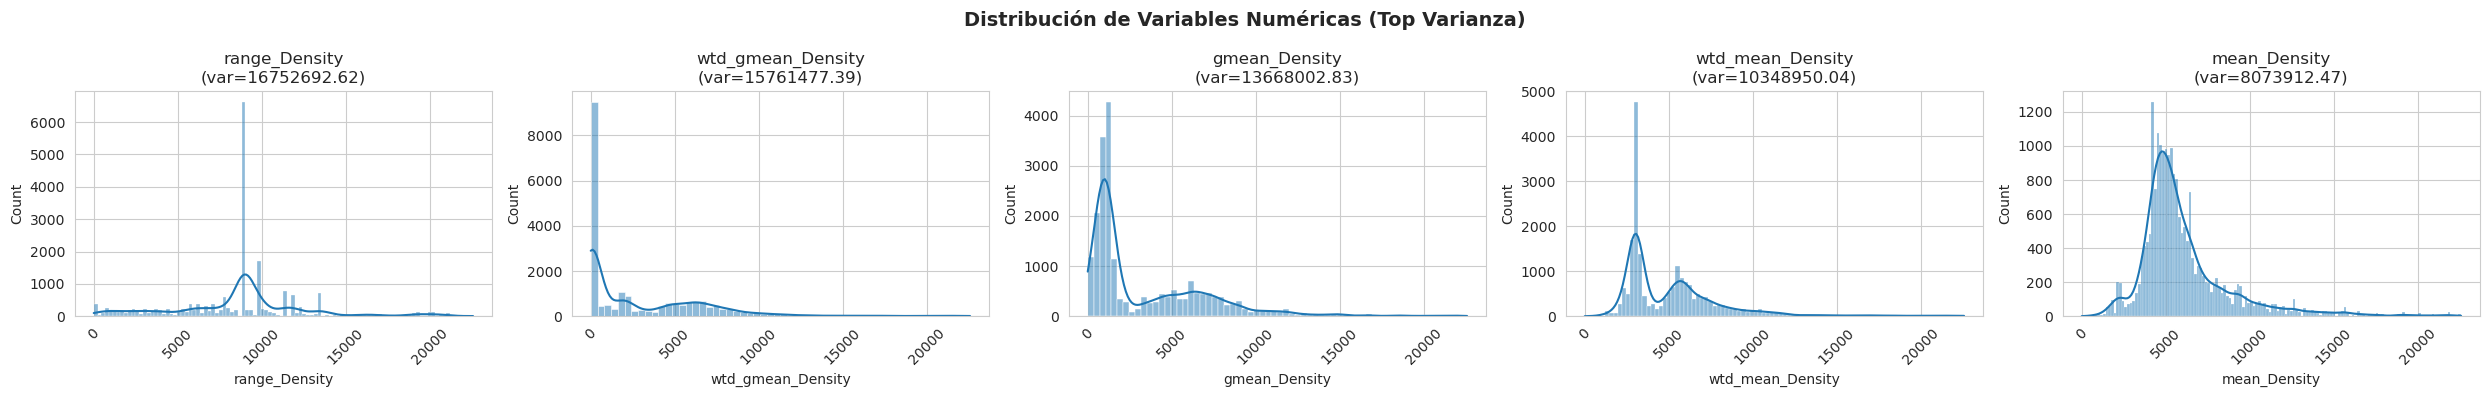

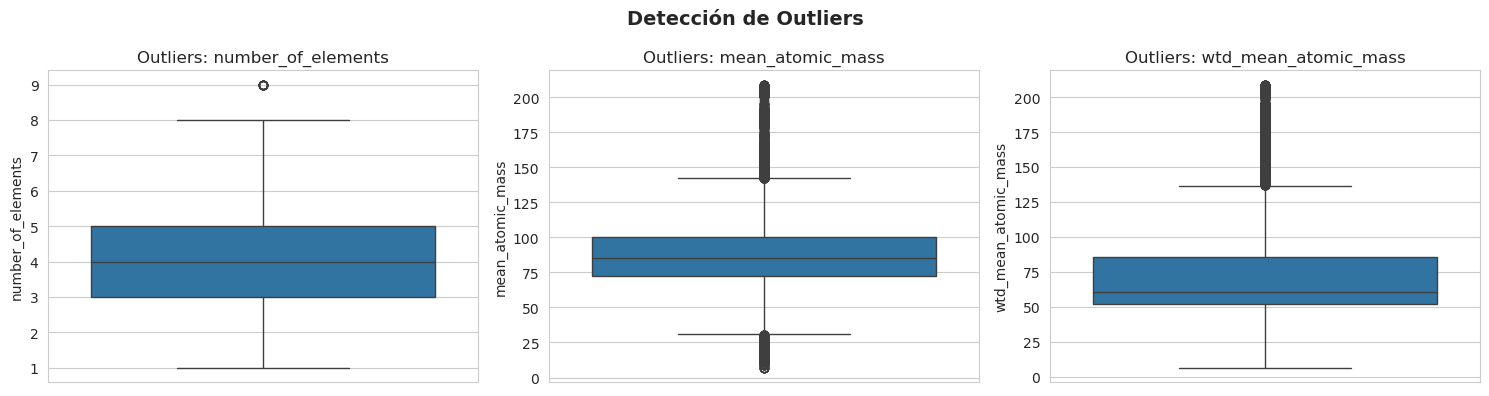

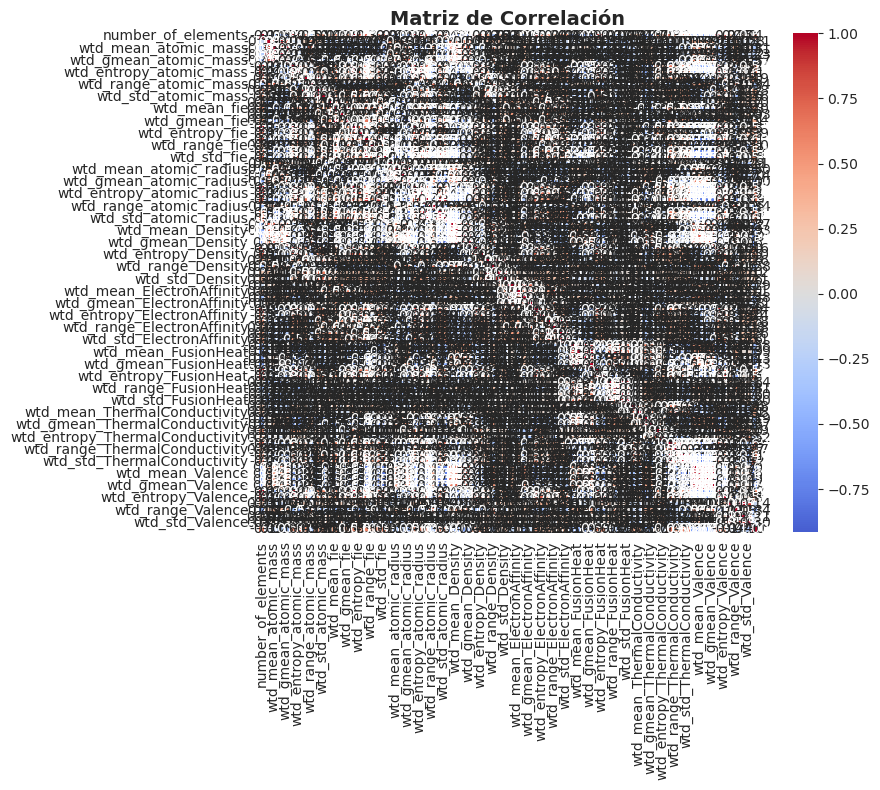

  ✓ EDA completado. Gráficos guardados en 'eda_plots/'

 Creando pipeline de ML...
  - Features numéricas: 81
  - Features categóricas: 0
  ✓ Pipeline creado exitosamente

✓ Reporte de calidad guardado: data_quality_report.csv

✓ No hay filas dañadas. No se generó archivo de auditoría.
✓ Dataset limpio guardado: dataset_limpio.csv

 LIMPIEZA Y CONVERSIÓN COMPLETADAS EXITOSAMENTE

 Resumen final:
  - Filas en dataset principal: 21197
  - Filas dañadas (auditoría): 0
  - Columnas originales: 82
  - Features temporales añadidas: 0
  - Columnas de duración añadidas: 0
  - Columnas finales: 82
  - Nulos restantes: 0
  - Target: critical_temp


In [7]:
df, pipeline, reporte, danadas, metadata = limpiar_y_convertir_dataset_completo('superconduct_train.csv',
                                                                               target_col = "critical_temp")

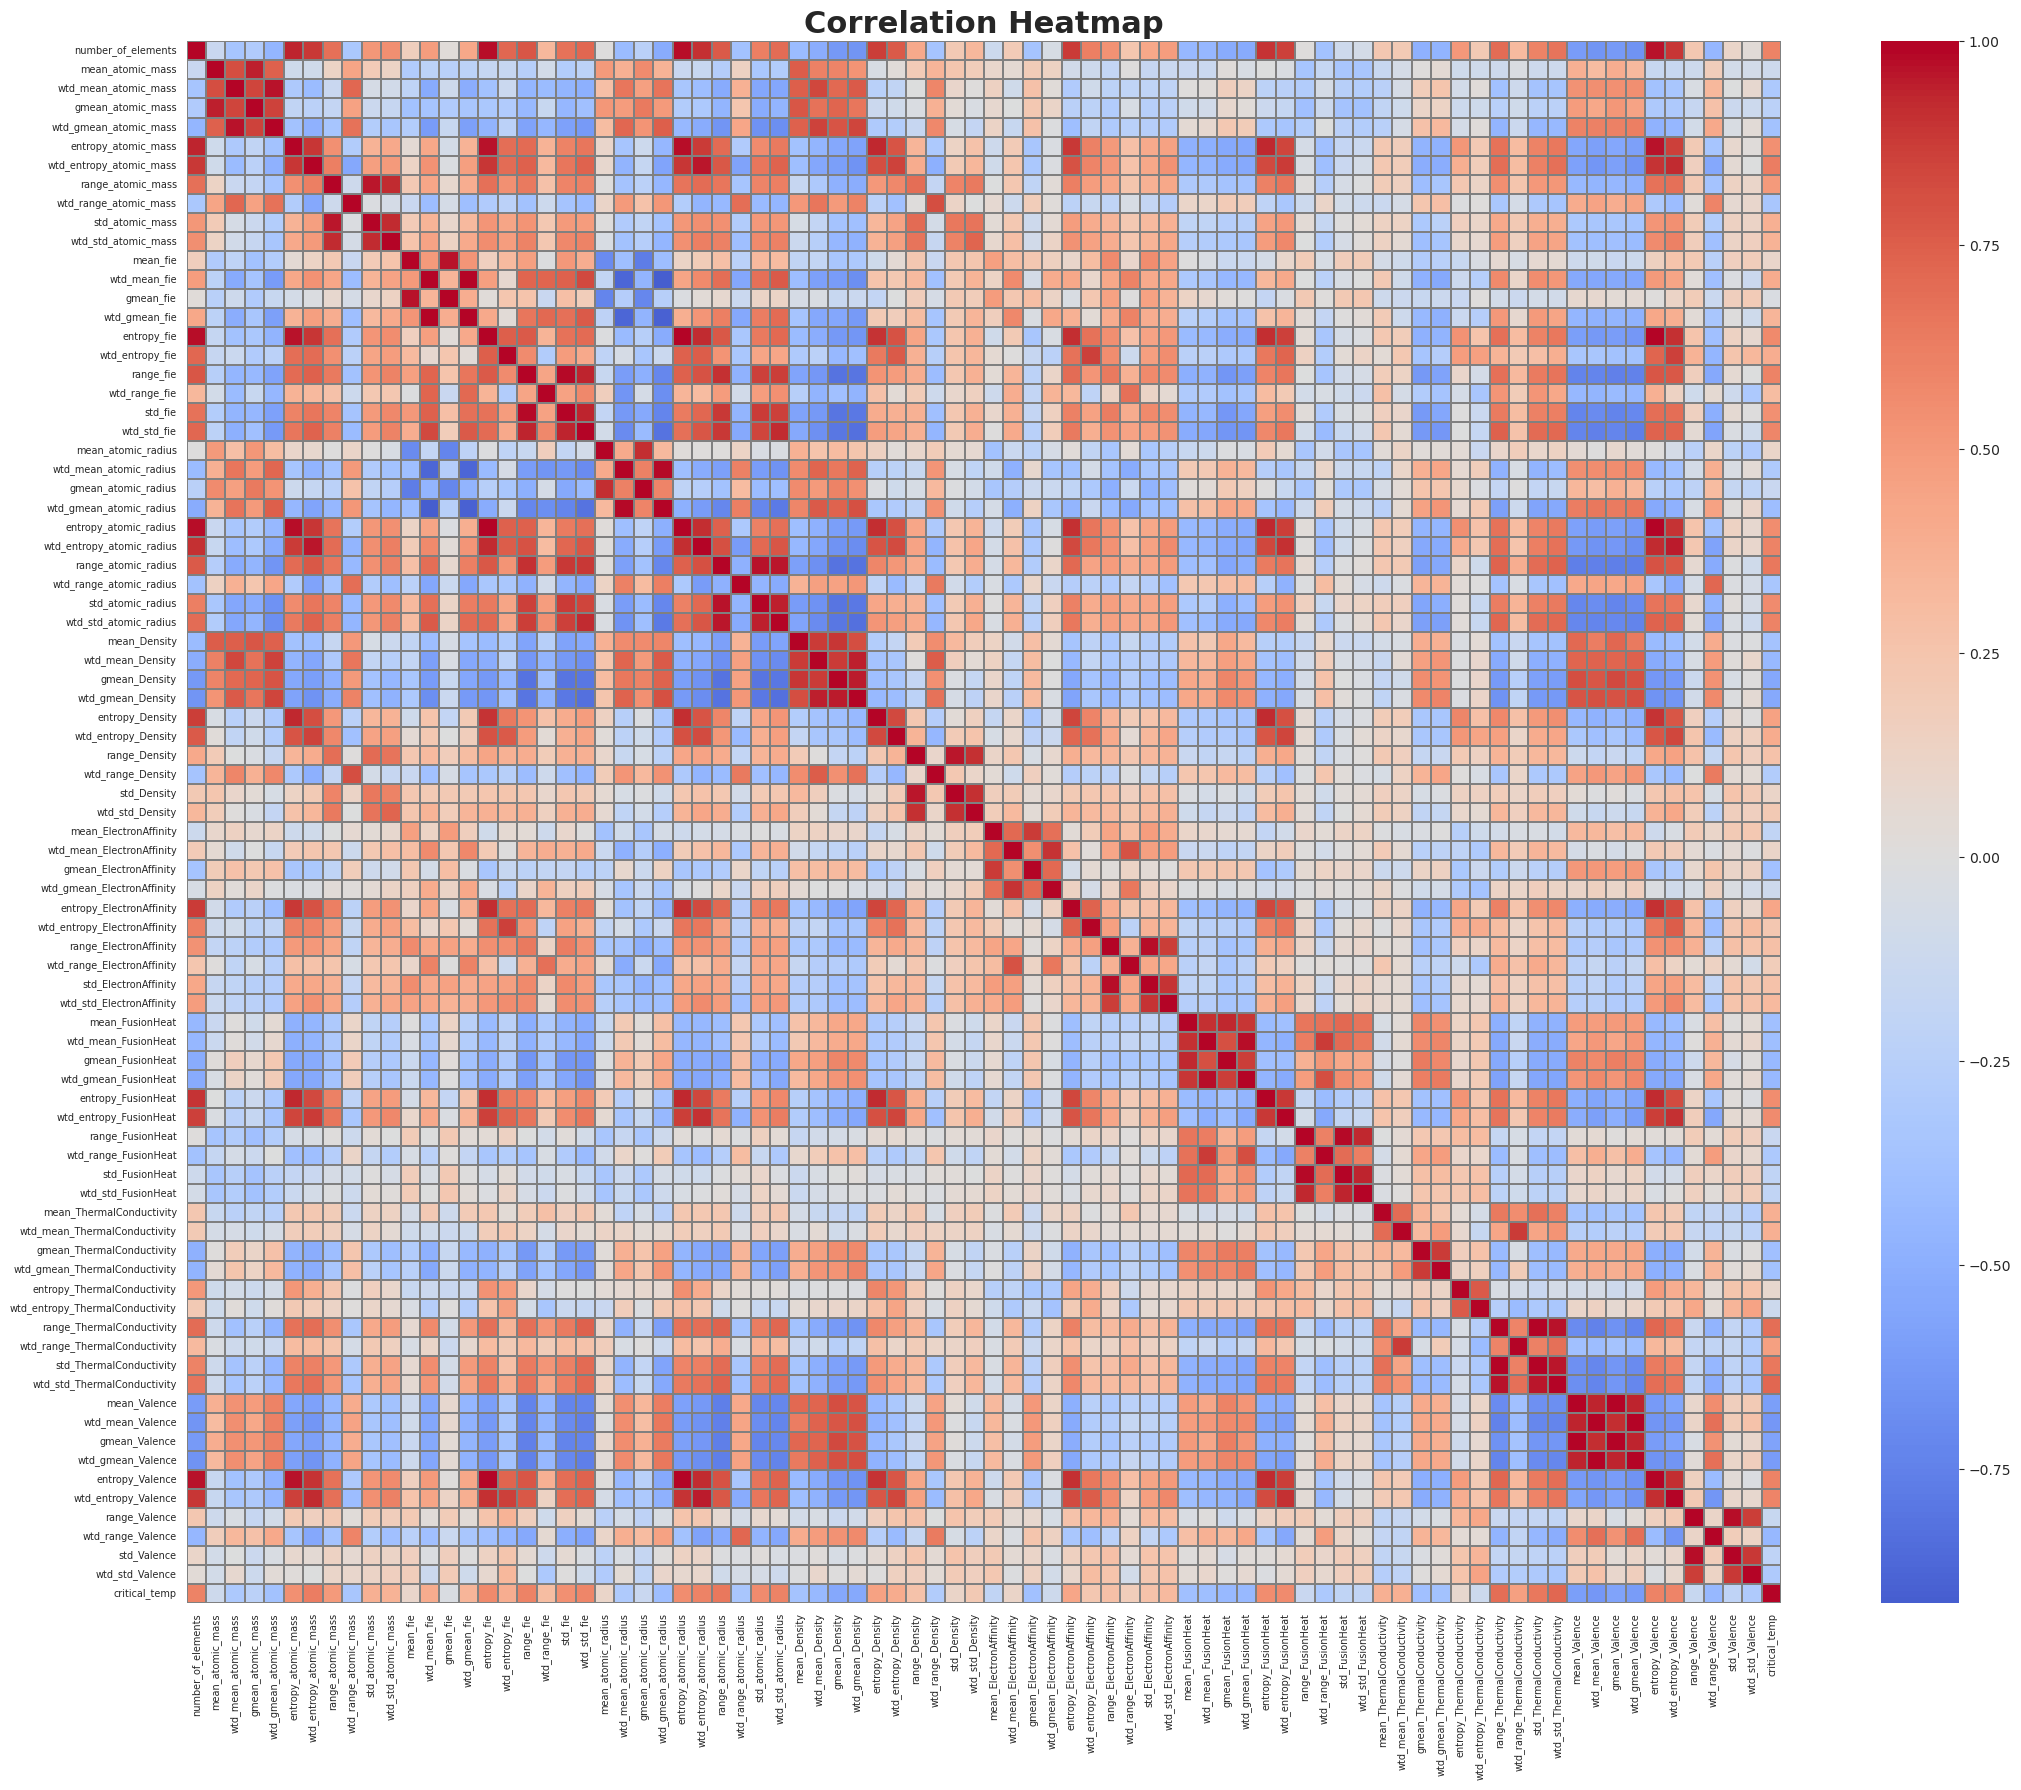

In [4]:
plt.figure(figsize=(22, 18))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,  # ← Importante: NO mostrar números (con 81 columnas sería ilegible)
    xticklabels=True,
    yticklabels=True,
    linewidths=0.1,
    linecolor='gray'
)

plt.title("Correlation Heatmap", fontsize=22, fontweight='bold')

# Ajustar tamaño de etiquetas para que sean legibles
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)

plt.tight_layout()
plt.show()